In [2]:
import pyguidos
import shutil
import rasterio
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
cwd = os.getcwd()

src_map = os.path.join(cwd, 'examples/data/binarymap.tif')
bin_map = os.path.join(cwd, 'examples/input/binarymap.tif')
shutil.copy(src_map, bin_map)


'/home/caudugi/git_rep/pyguidosx/examples/input/binarymap.tif'

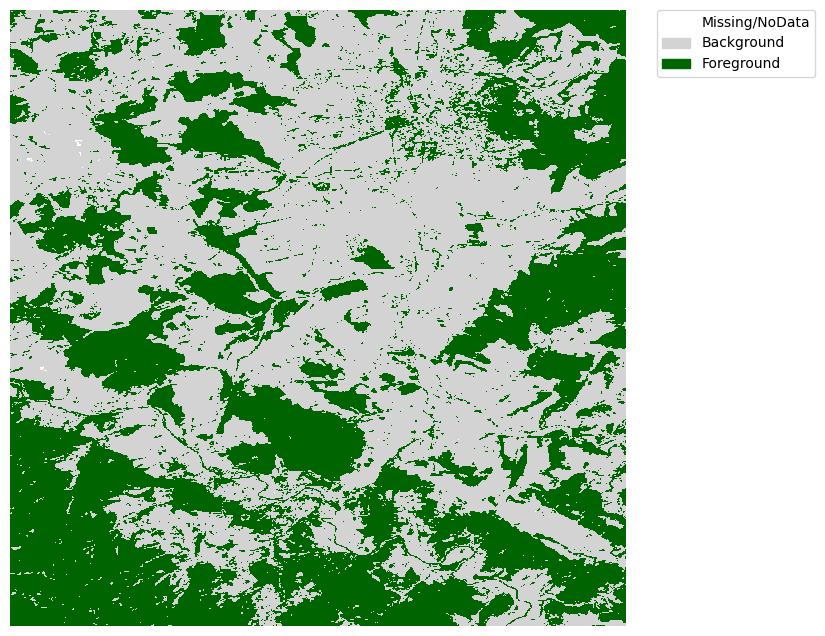

In [27]:
with rasterio.open(bin_map) as src:
    data = src.read(1)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['white', 'lightgrey', 'darkgreen'] 
cmap = ListedColormap(colors)
im = ax.imshow(data, cmap=cmap, vmin=-0.5, vmax=2.5)
legend_labels = {
    0: 'Missing/NoData', 
    1: 'Background',     
    2: 'Foreground'      
}

patches = []
for val in sorted(legend_labels.keys()): 
    label = legend_labels[val]
    color = colors[val] 
    patch = mpatches.Patch(color=color, label=label)
    patches.append(patch)
legend = ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.axis('off')
plt.show()

In [8]:
in_dir = os.path.join(cwd, 'examples/input')
out_dir = os.path.join(cwd, 'examples/output')


pyguidos.gwb_sc(in_dir, out_dir, R=81, W=27, A=2)

GWB_SC using:
dir_input= /home/caudugi/git_rep/pyguidosx/examples/input
dir_output= /home/caudugi/git_rep/pyguidosx/examples/output
Done with: binarymap.tif
SC-rule 81 finished sucessfully



In [9]:
map_name = bin_map.split('/')[-1][:-4]
res_dir = os.path.join(cwd, 'examples/output', map_name + '_rule81_27')

sc_map = os.path.join(res_dir, map_name + '_rule81_27.tif')

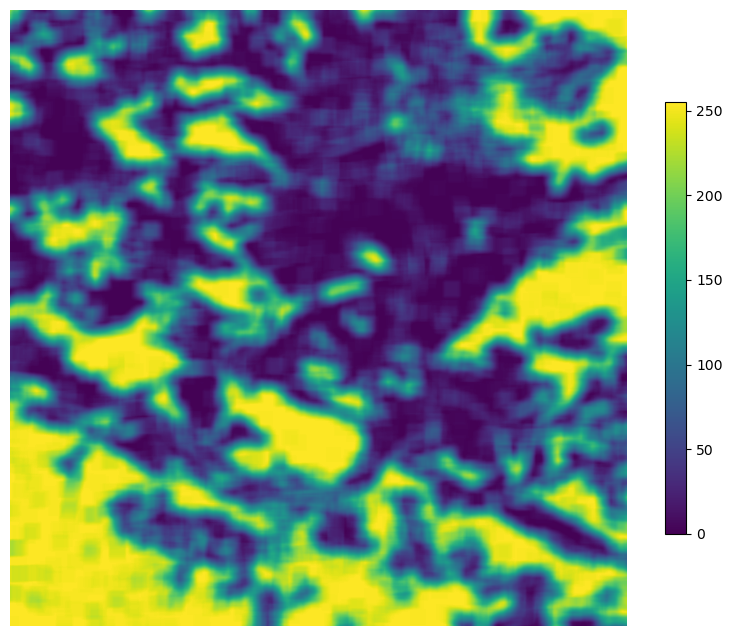

In [14]:
with rasterio.open(sc_map) as src:
    data = src.read(1)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data, vmin=0, vmax=255)
cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.7)

plt.axis('off')
plt.show()